# PCA-анализ латентного пространства DNAR для алгоритма Дейкстры

Этот ноутбук воспроизводит методологию PCA-анализа из статьи
«Latent Space Representations of Neural Algorithmic Reasoners» (arXiv:2307.08874v2, Mirjanić, Pascanu, Veličković, LoG 2023)
применительно к модели **DNAR** (Discrete Neural Algorithmic Reasoning) на алгоритме **Дейкстры**.

## Структура анализа

1. **Извлечение латентных траекторий** — скрытые представления узлов на каждом шаге процессора
2. **Trajectory-wise PCA** — каждый граф как одна точка в 2D/3D
3. **Step-wise PCA** — каждый шаг каждого графа как точка, с линиями траекторий
4. **Анализ размерности** — объяснённая дисперсия топ-3 PCA компонент
5. **Симметрия масштабирования** — влияние масштабирования весов рёбер
6. **(Опционально) Симметрия перевзвешивания** — экспериментальный анализ

## Требования к окружению

Помимо зависимостей из `requirements.txt` репозитория DNAR, дополнительно нужны:
```
pip install scikit-learn matplotlib seaborn
```

**Важно:** перед запуском ноутбука необходимо обучить модель:
```bash
python train.py --config_path ./configs/dijkstra.yaml
```
Ноутбук ожидает наличие чекпойнта в `models/dijkstra_42_last`.


## 1. Импорт библиотек и настройка окружения

In [ ]:
!git clone https://github.com/artlvruran/dnar.git
%cd dnar
!pip install -r requirements.txt
!pip install scikit-learn matplotlib seaborn

Cloning into 'dnar'...
remote: Enumerating objects: 714, done.
remote: Counting objects: 100% (582/582), done.
remote: Compressing objects: 100% (330/330), done.
remote: Total 714 (delta 288), reused 505 (delta 244), pack-reused 132 (from 1)
Receiving objects: 100% (714/714), 21.03 MiB | 27.44 MiB/s, done.
Resolving deltas: 100% (318/318), done.
/content/dnar
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00


In [ ]:
import os
import math
import copy

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch_geometric.utils import scatter
from torch_geometric.data import Data
from tqdm import tqdm

# Импорты из репозитория DNAR
from configs import base_config
from models import Dnar
from generate_data import (
    create_dataloader,
    ErdosRenyiGraphSampler,
    ProblemInstance,
    dijkstra,
    ALGORITHMS,
)
from utils import reverse_edge_index

# Настройки визуализации
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Устройство: cuda


## 2. Загрузка конфигурации и обученной модели

Загружаем конфигурацию для Дейкстры и восстанавливаем модель из чекпойнта.
Если чекпойнта нет — запустите `python train.py --config_path ./configs/dijkstra.yaml`.

In [ ]:
CONFIG_PATH = './configs/dijkstra.yaml'
CHECKPOINT_PATH = '../dijkstra_47_last_dnar_attn'  # путь к обученной модели

config = base_config.read_config(CONFIG_PATH)
print(f'Алгоритм: {config.algorithm}')
print(f'Латентная размерность h: {config.h}')
print(f'num_node_states: {config.num_node_states}')
print(f'num_edge_states: {config.num_edge_states}')
print(f'Размер обучающей выборки: {config.problem_size}')

assert os.path.exists(CHECKPOINT_PATH), (
    f'Чекпойнт не найден: {CHECKPOINT_PATH}.\n'
    f'Обучите модель: python train.py --config_path ./configs/dijkstra.yaml'
)

# DNAR использует DoubleTensor
torch.set_default_tensor_type(torch.DoubleTensor)

model = Dnar(config).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print('Модель загружена успешно.')


Алгоритм: dijkstra
Латентная размерность h: 128
num_node_states: 2
num_edge_states: 2
Размер обучающей выборки: {'train': 16, 'val': 16, 'test': 64}


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1323: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


Модель загружена успешно.


## 3. Генерация тестовых данных

Создаём выборку случайных графов Эрдёша–Реньи с весами на рёбрах.
Для корректного PCA-анализа все графы должны иметь одинаковую длину траектории T.
В DNAR для Дейкстры траектория всегда имеет длину T = n (число узлов),
поскольку цикл выполняется ровно n-1 раз плюс начальный шаг.

In [ ]:
# Генерируем данные для анализа (val split, но с фиксированным размером)
ANALYSIS_NUM_NODES = 64  # размер графов для анализа (как в train/val)
ANALYSIS_NUM_SAMPLES = 500  # число графов для PCA

# Создаём модифицированный конфиг для генерации данных
analysis_config = copy.deepcopy(config)
analysis_config.num_samples = {'train': 0, 'val': ANALYSIS_NUM_SAMPLES, 'test': 0}
analysis_config.problem_size = {
    'train': ANALYSIS_NUM_NODES,
    'val': ANALYSIS_NUM_NODES,
    'test': ANALYSIS_NUM_NODES,
}

dataloader = create_dataloader(analysis_config, 'val', seed=SEED, device=DEVICE)

# Проверяем, что все графы имеют одинаковую длину траектории
for batch in dataloader:
    T = batch.node_fts.shape[1]
    print(f'Число узлов: {ANALYSIS_NUM_NODES}')
    print(f'Длина траектории T: {T}')
    print(f'Размер батча: {batch.num_graphs}')
    print(f'Размерность node_fts: {batch.node_fts.shape}')
    break


Generate samples for val: 100%|██████████| 500/500 [00:12<00:00, 38.97it/s]


Число узлов: 64
Длина траектории T: 64
Размер батча: 32
Размерность node_fts: torch.Size([2048, 64, 2])


## 4. Извлечение латентных траекторий

Аналогично методу из статьи, мы записываем полные траектории скрытых представлений:

- **z_v^(i)** — скрытое представление узла v на шаге i (128-мерный вектор)
- Тензор траекторий имеет форму **N × |V| × D × T**

В DNAR непрерывные латентные представления — это `node_fts` на выходе
`AttentionModule` (message passing) + FFN, **до** дискретизации в `StatesBottleneck`.

Мы пишем кастомный forward, который:
1. Проходит по шагам процессора (как в `models.py`)
2. На каждом шаге вызывает `message_passing` и `ffn` для получения `node_fts`
3. Сохраняет `node_fts` для каждого шага
4. Затем продолжает с `states_bottleneck` и `scalar_update` для корректной работы модели

In [ ]:
def extract_latent_trajectories(model, batch, device):
    """
    Извлекает латентные траектории node_fts из модели DNAR.

    Возвращает:
        node_latents: список тензоров [num_nodes_in_batch, D] для каждого шага
        edge_latents: список тензоров [num_edges_in_batch, D] для каждого шага
    """
    processor = model.processor
    batch.batched_reverse_idx = reverse_edge_index(batch.edge_index)

    T = batch.node_fts.shape[1]
    teacher_force = False  # inference mode
    training_step = -1  # eval mode

    node_states = batch.node_fts[:, 0]
    edge_states = batch.edge_fts[:, 0]
    cur_step_scalars = batch.scalars[:, 0]

    node_latents = []  # непрерывные представления узлов
    edge_latents = []  # непрерывные представления рёбер

    # Начальное представление (шаг 0) — после первого message passing
    with torch.no_grad():
        for processor_step in range(1, T):
            # --- Message passing ---
            node_fts, edge_fts = processor.message_passing(
                node_states, edge_states, cur_step_scalars, batch, training_step
            )
            # --- FFN ---
            node_fts, edge_fts = processor.ffn(node_fts, edge_fts, batch)

            # Сохраняем латентные представления (после FFN, до bottleneck)
            node_latents.append(node_fts.clone())
            edge_latents.append(edge_fts.clone())

            # --- States bottleneck (дискретизация) ---
            node_states, edge_states, states_loss = processor.states_bottleneck(
                node_fts, edge_fts, batch, training_step, processor_step, teacher_force
            )

            # --- Scalar update ---
            cur_step_scalars, scalars_loss = processor.scalar_update(
                node_states, edge_states, cur_step_scalars, batch,
                training_step, processor_step, teacher_force
            )

    return node_latents, edge_latents


def collect_trajectories(model, dataloader, device, max_graphs=None):
    """
    Собирает латентные траектории для всех графов из даталоадера.

    Возвращает:
        all_node_latents: тензор [N, |V|, D, T] — латентные представления узлов
        graph_batch_indices: список batch-индексов для каждого графа
        T: число шагов
    """
    all_node_latents_per_graph = []  # список [list of (|V|, D) per step]
    all_edge_latents_per_graph = []
    num_graphs_total = 0

    for batch in tqdm(dataloader, desc='Извлечение латентных траекторий'):
        node_latents, edge_latents = extract_latent_trajectories(model, batch, device)
        T = len(node_latents)
        D = node_latents[0].shape[-1]

        # Разделяем по графам в батче
        num_graphs = batch.num_graphs
        for g_idx in range(num_graphs):
            # Маска узлов для графа g_idx
            node_mask = (batch.batch == g_idx)
            # Маска рёбер для графа g_idx
            edge_mask = (batch.batch[batch.edge_index[0]] == g_idx)

            graph_node_steps = []
            for step in range(T):
                graph_node_steps.append(node_latents[step][node_mask].cpu().numpy())

            all_node_latents_per_graph.append(graph_node_steps)
            num_graphs_total += 1

            if max_graphs is not None and num_graphs_total >= max_graphs:
                break

        if max_graphs is not None and num_graphs_total >= max_graphs:
            break

    # Преобразуем в единый тензор [N, |V|, D, T]
    N = len(all_node_latents_per_graph)
    V = all_node_latents_per_graph[0][0].shape[0]
    D = all_node_latents_per_graph[0][0].shape[1]
    T = len(all_node_latents_per_graph[0])

    trajectories = np.zeros((N, V, D, T))
    for i, graph_steps in enumerate(all_node_latents_per_graph):
        for t in range(T):
            trajectories[i, :, :, t] = graph_steps[t]

    print(f'Собрано траекторий: N={N}, узлов V={V}, размерность D={D}, шагов T={T}')
    return trajectories


Извлекаем латентные траектории для всех графов:

In [ ]:
trajectories = collect_trajectories(model, dataloader, DEVICE, max_graphs=ANALYSIS_NUM_SAMPLES)
N, V, D, T = trajectories.shape
print(f'Форма тензора траекторий: {trajectories.shape}')


Извлечение латентных траекторий:  94%|█████████▍| 15/16 [00:54<00:03,  3.67s/it]


Собрано траекторий: N=500, узлов V=64, размерность D=128, шагов T=63
Форма тензора траекторий: (500, 64, 128, 63)


## 5. Агрегация по узлам

По методологии статьи, для уменьшения оси узлов (|V|) мы применяем **max-агрегацию**:

$$\text{для каждого шага } i: \quad \mathbf{z}^{(i)} = \max_v \mathbf{z}_v^{(i)}$$

Это преобразует тензор из **N × |V| × D × T** в **N × D × T**.

Также рассматриваем mean-агрегацию для сравнения (как в Appendix C.2 статьи).

In [ ]:
# Max-агрегация по оси узлов
trajectories_max = trajectories.max(axis=1)  # [N, D, T]
print(f'После max-агрегации: {trajectories_max.shape}')

# Mean-агрегация для сравнения
trajectories_mean = trajectories.mean(axis=1)  # [N, D, T]
print(f'После mean-агрегации: {trajectories_mean.shape}')

# Используем max по умолчанию (как в основной части статьи)
trajectories_agg = trajectories_max
AGG_NAME = 'max'


После max-агрегации: (500, 128, 63)
После mean-агрегации: (500, 128, 63)


## 6. Trajectory-wise PCA

Объединяем ось размерности и ось шагов, создавая матрицу размера **N × (D·T)**.
Каждый граф представлен одной точкой. Снижаем размерность до 2D и 3D.

- **X axis** — направление наибольшей дисперсии
- **Y axis** — направление второй по величине дисперсии

In [ ]:
# Подготовка матрицы для trajectory-wise PCA
# trajectories_agg имеет форму [N, D, T] -> [N, D*T]
traj_matrix = trajectories_agg.reshape(N, D * T)
print(f'Trajectory-wise матрица: {traj_matrix.shape}')

# PCA до 3 компонент
pca_traj = PCA(n_components=3)
traj_pca = pca_traj.fit_transform(traj_matrix)
print(f'Объяснённая дисперсия (trajectory-wise): {pca_traj.explained_variance_ratio_}')
print(f'Суммарная (топ-3): {pca_traj.explained_variance_ratio_.sum():.4f}')


Trajectory-wise матрица: (500, 8064)
Объяснённая дисперсия (trajectory-wise): [0.29746291 0.06706157 0.05226976]
Суммарная (топ-3): 0.4168


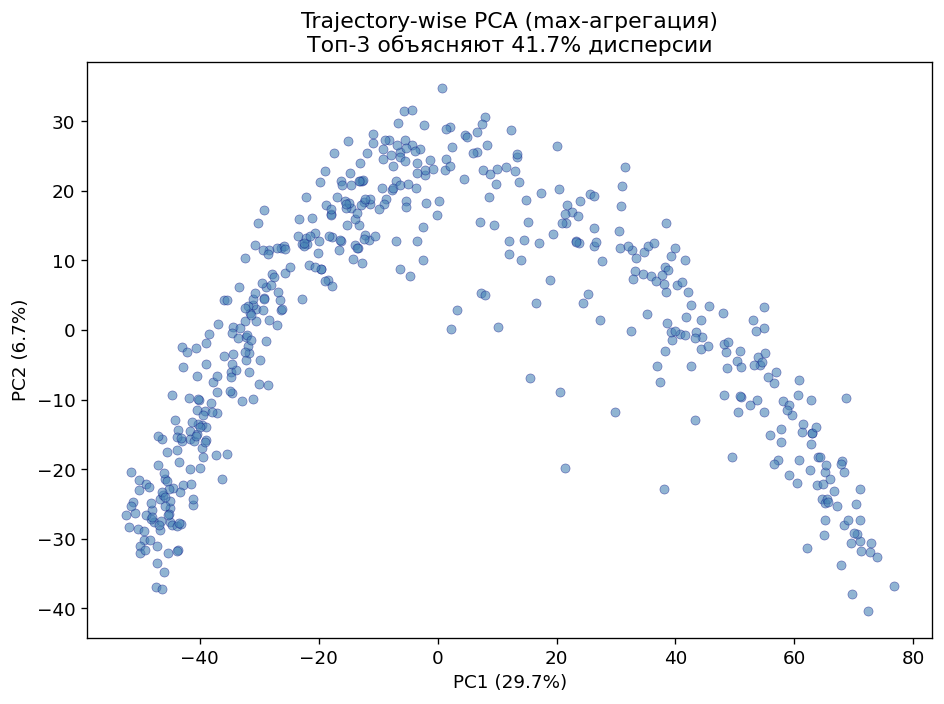

In [ ]:
# Визуализация trajectory-wise PCA (2D)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(traj_pca[:, 0], traj_pca[:, 1], c='steelblue', alpha=0.6, s=30, edgecolors='navy', linewidths=0.3)
ax.set_xlabel(f'PC1 ({pca_traj.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_traj.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Trajectory-wise PCA (max-агрегация)\nТоп-3 объясняют {pca_traj.explained_variance_ratio_.sum()*100:.1f}% дисперсии')
plt.tight_layout()
plt.savefig('pca_trajectory_wise_2d.png', dpi=150, bbox_inches='tight')
plt.show()


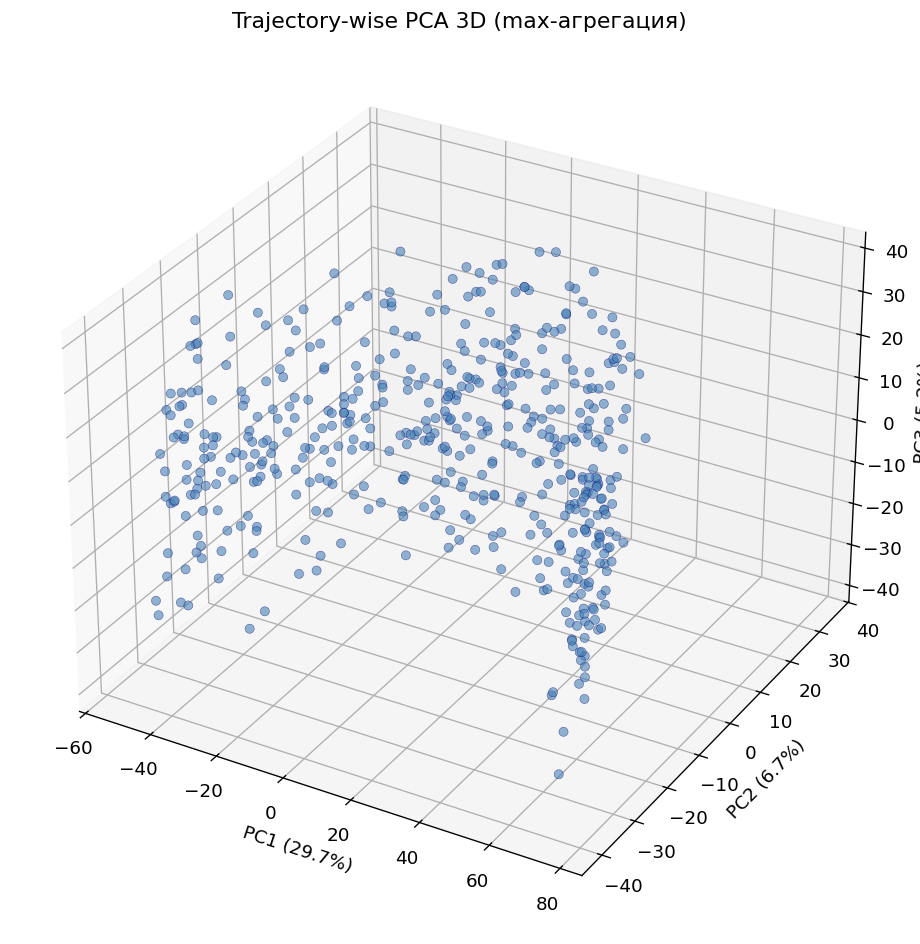

In [ ]:
# Визуализация trajectory-wise PCA (3D)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2], c='steelblue', alpha=0.6, s=30, edgecolors='navy', linewidths=0.3)
ax.set_xlabel(f'PC1 ({pca_traj.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_traj.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_traj.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title(f'Trajectory-wise PCA 3D (max-агрегация)')
plt.tight_layout()
plt.savefig('pca_trajectory_wise_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Step-wise PCA

Объединяем ось шагов и ось графов, создавая матрицу размера **(N·T) × D**.
Каждый граф представлен T точками (по одной на каждый шаг).
Рисуем красные линии через T точек каждого графа, точки раскрашены по шагу.

In [ ]:
# Подготовка матрицы для step-wise PCA
# trajectories_agg имеет форму [N, D, T] -> [N*T, D]
step_matrix = np.transpose(trajectories_agg, (0, 2, 1)).reshape(N * T, D)
print(f'Step-wise матрица: {step_matrix.shape}')

# PCA до 3 компонент
pca_step = PCA(n_components=3)
step_pca = pca_step.fit_transform(step_matrix)
print(f'Объяснённая дисперсия (step-wise): {pca_step.explained_variance_ratio_}')
print(f'Суммарная (топ-3): {pca_step.explained_variance_ratio_.sum():.4f}')

# Восстанавливаем форму [N, T, 3] для рисования траекторий
step_pca_reshaped = step_pca.reshape(N, T, 3)


Step-wise матрица: (31500, 128)
Объяснённая дисперсия (step-wise): [0.58756633 0.17819166 0.07432434]
Суммарная (топ-3): 0.8401


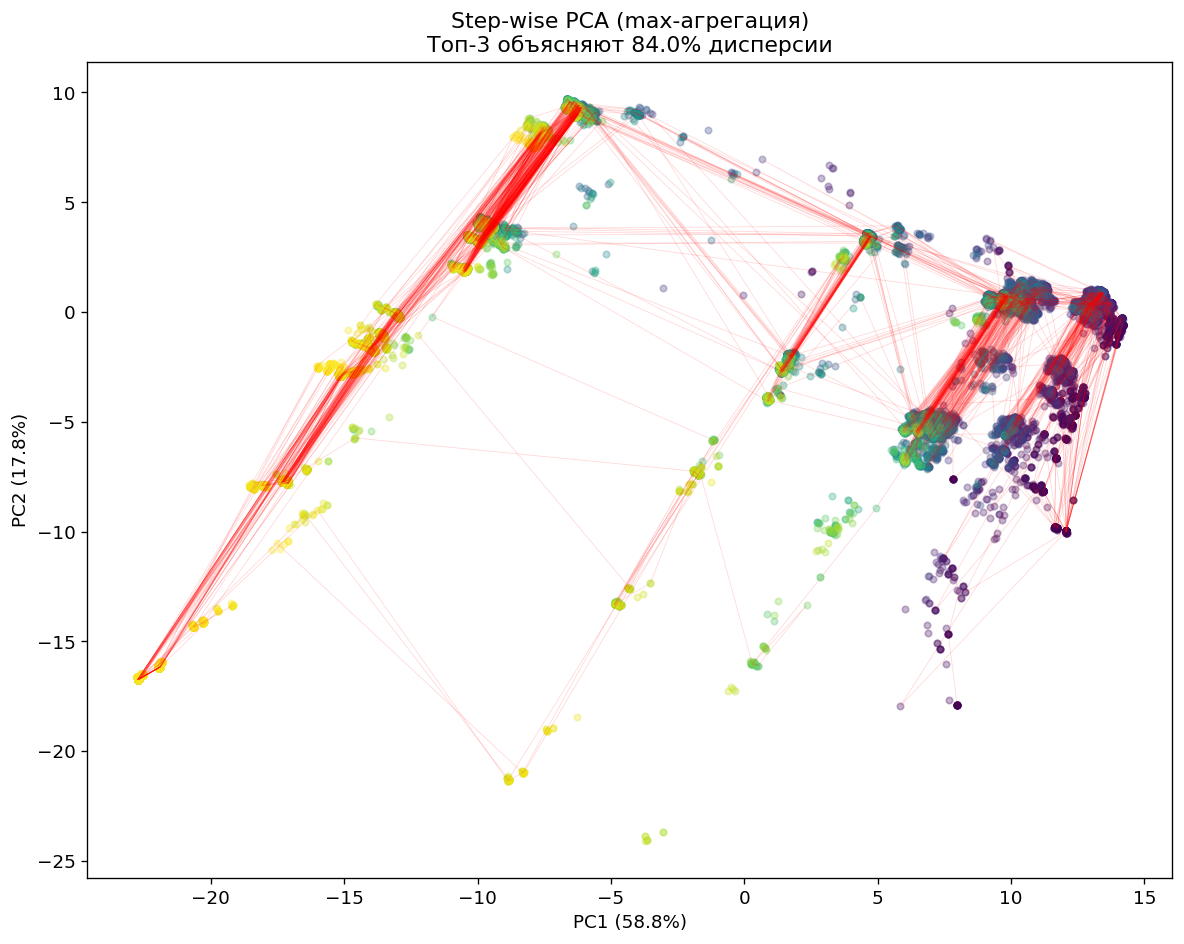

In [ ]:
# Визуализация step-wise PCA (2D) с линиями траекторий
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Цветовая карта по шагам
cmap = plt.cm.viridis
step_colors = np.array([cmap(t / (T - 1)) for t in range(T)])

# Рисуем точки, раскрашенные по шагу
for t in range(T):
    ax.scatter(step_pca_reshaped[:, t, 0], step_pca_reshaped[:, t, 1],
               color=step_colors[t], alpha=0.3, s=15, label=f'Шаг {t}' if t % 3 == 0 or t == T-1 else '')

# Рисуем красные линии через траектории нескольких графов
num_traj_to_draw = min(50, N)  # рисуем не все, чтобы не загромождать
indices = np.random.choice(N, num_traj_to_draw, replace=False)
for i in indices:
    ax.plot(step_pca_reshaped[i, :, 0], step_pca_reshaped[i, :, 1],
            color='red', alpha=0.15, linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_step.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_step.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Step-wise PCA (max-агрегация)\nТоп-3 объясняют {pca_step.explained_variance_ratio_.sum()*100:.1f}% дисперсии')
if T <= 20:
    ax.legend(fontsize=7, loc='best', markerscale=2)
plt.tight_layout()
plt.savefig('pca_step_wise_2d.png', dpi=150, bbox_inches='tight')
plt.show()


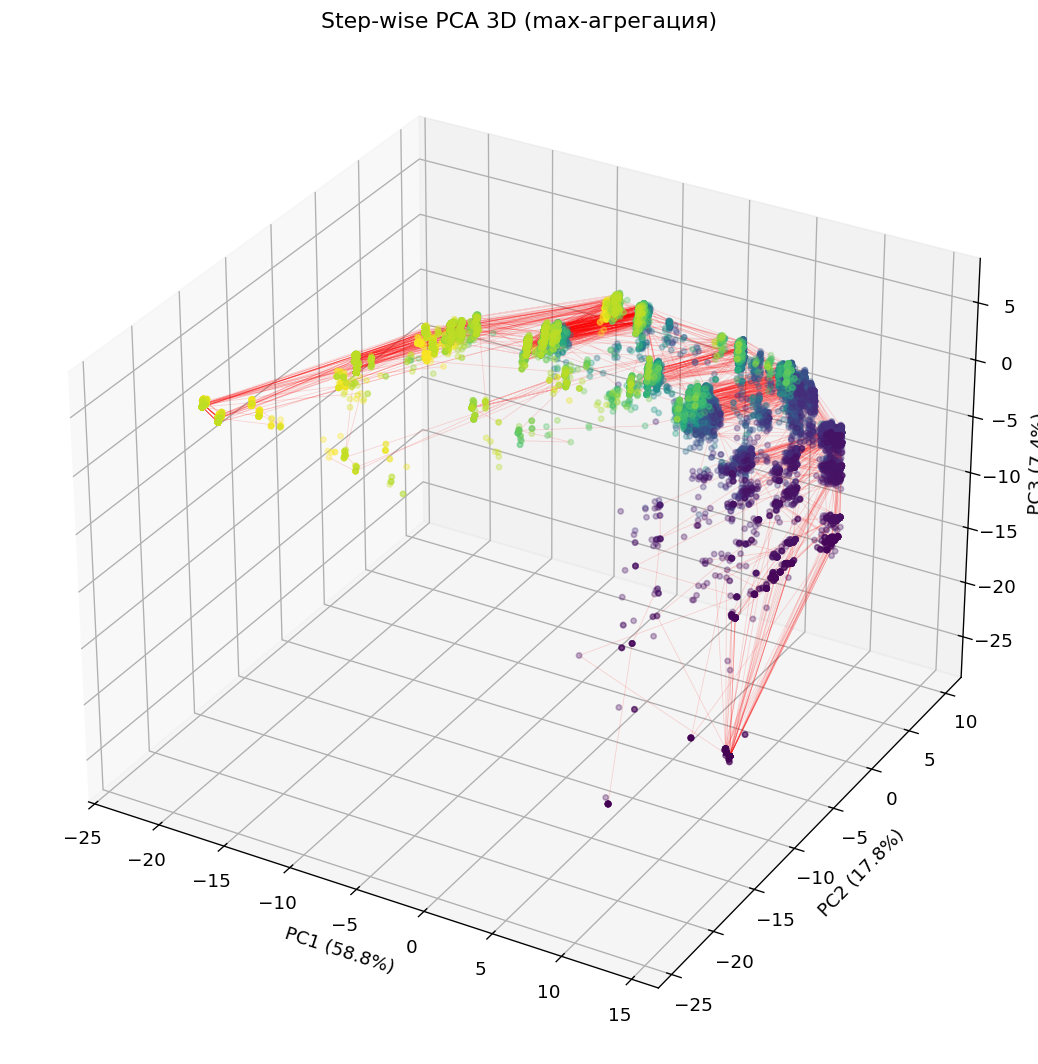

In [ ]:
# Визуализация step-wise PCA (3D) с линиями траекторий
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Точки, раскрашенные по шагу
for t in range(T):
    ax.scatter(step_pca_reshaped[:, t, 0], step_pca_reshaped[:, t, 1], step_pca_reshaped[:, t, 2],
               color=step_colors[t], alpha=0.3, s=10)

# Красные линии траекторий
for i in indices:
    ax.plot(step_pca_reshaped[i, :, 0], step_pca_reshaped[i, :, 1], step_pca_reshaped[i, :, 2],
            color='red', alpha=0.15, linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_step.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_step.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_step.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('Step-wise PCA 3D (max-агрегация)')
plt.tight_layout()
plt.savefig('pca_step_wise_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Анализ размерности латентного пространства

Проверяем, насколько латентное пространство ниже размерности, чем номинальные 128 измерений.
Измеряем долю дисперсии, объясняемую топ-3 PCA компонентами.

Для сравнения: при равномерном распределении по 128 измерениям первые 3 компоненты
объясняли бы лишь 3/128 ≈ 2.3% дисперсии.

In [ ]:
# Полный PCA для анализа объяснённой дисперсии
pca_traj_full = PCA(n_components=min(D * T, N, 128))
pca_traj_full.fit(traj_matrix)

pca_step_full = PCA(n_components=min(D, N * T))
pca_step_full.fit(step_matrix)

# Топ-3 объяснённая дисперсия
traj_top3 = pca_traj_full.explained_variance_ratio_[:3].sum()
step_top3 = pca_step_full.explained_variance_ratio_[:3].sum()

print('=' * 60)
print('Анализ размерности латентного пространства')
print('=' * 60)
print(f'Trajectory-wise PCA (топ-3): {traj_top3*100:.1f}%')
print(f'  PC1: {pca_traj_full.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca_traj_full.explained_variance_ratio_[1]*100:.1f}%')
print(f'  PC3: {pca_traj_full.explained_variance_ratio_[2]*100:.1f}%')
print()
print(f'Step-wise PCA (топ-3): {step_top3*100:.1f}%')
print(f'  PC1: {pca_step_full.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca_step_full.explained_variance_ratio_[1]*100:.1f}%')
print(f'  PC3: {pca_step_full.explained_variance_ratio_[2]*100:.1f}%')
print()
print(f'Ожидаемое значение при равномерном распределении по {D} измерениям: {3/D*100:.1f}%')
print()
print('Вывод: латентное пространство значительно ниже размерности, чем D=128,')
print('что говорит о богатой структуре скрытых представлений.')


Анализ размерности латентного пространства
Trajectory-wise PCA (топ-3): 41.7%
  PC1: 29.7%
  PC2: 6.7%
  PC3: 5.2%

Step-wise PCA (топ-3): 84.0%
  PC1: 58.8%
  PC2: 17.8%
  PC3: 7.4%

Ожидаемое значение при равномерном распределении по 128 измерениям: 2.3%

Вывод: латентное пространство значительно ниже размерности, чем D=128,
что говорит о богатой структуре скрытых представлений.


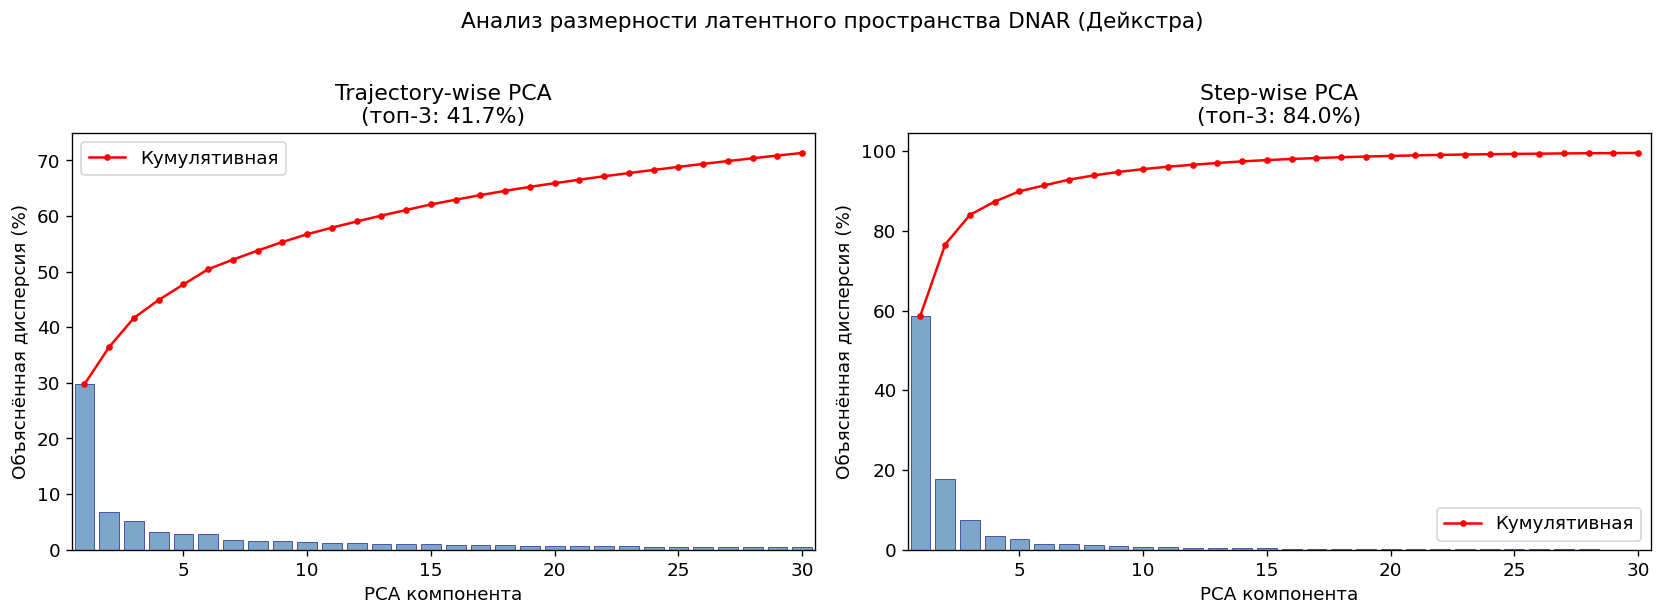

In [ ]:
# График кумулятивной объяснённой дисперсии
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectory-wise
n_components_traj = min(30, len(pca_traj_full.explained_variance_ratio_))
axes[0].bar(range(1, n_components_traj + 1),
            pca_traj_full.explained_variance_ratio_[:n_components_traj] * 100,
            color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)
axes[0].plot(range(1, n_components_traj + 1),
             np.cumsum(pca_traj_full.explained_variance_ratio_[:n_components_traj]) * 100,
             color='red', marker='o', markersize=3, linewidth=1.5, label='Кумулятивная')
axes[0].set_xlabel('PCA компонента')
axes[0].set_ylabel('Объяснённая дисперсия (%)')
axes[0].set_title(f'Trajectory-wise PCA\n(топ-3: {traj_top3*100:.1f}%)')
axes[0].legend()
axes[0].set_xlim(0.5, n_components_traj + 0.5)

# Step-wise
n_components_step = min(30, len(pca_step_full.explained_variance_ratio_))
axes[1].bar(range(1, n_components_step + 1),
            pca_step_full.explained_variance_ratio_[:n_components_step] * 100,
            color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)
axes[1].plot(range(1, n_components_step + 1),
             np.cumsum(pca_step_full.explained_variance_ratio_[:n_components_step]) * 100,
             color='red', marker='o', markersize=3, linewidth=1.5, label='Кумулятивная')
axes[1].set_xlabel('PCA компонента')
axes[1].set_ylabel('Объяснённая дисперсия (%)')
axes[1].set_title(f'Step-wise PCA\n(топ-3: {step_top3*100:.1f}%)')
axes[1].legend()
axes[1].set_xlim(0.5, n_components_step + 0.5)

plt.suptitle('Анализ размерности латентного пространства DNAR (Дейкстра)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Сравнение агрегаций: max vs mean

В статье (Appendix C.2) показано, что mean-агрегация увеличивает объяснённую дисперсию
trajectory-wise PCA с 63% до 94%. Проверяем это для DNAR.

Сравнение агрегаций (топ-3 объяснённая дисперсия):
  Trajectory-wise (max):  41.7%
  Trajectory-wise (mean): 82.9%
  Step-wise (max):        84.0%
  Step-wise (mean):       99.5%


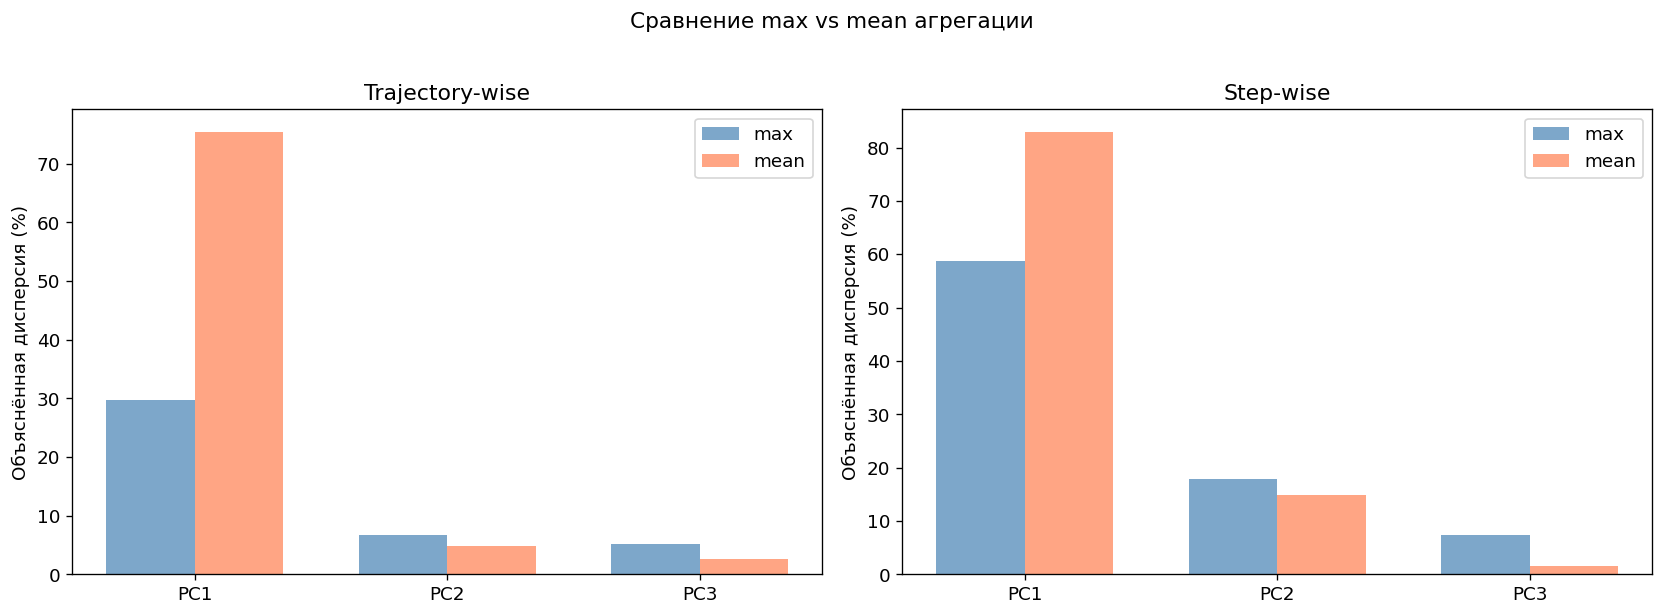

In [ ]:
# Trajectory-wise PCA с mean-агрегацией
traj_matrix_mean = trajectories_mean.reshape(N, D * T)
pca_traj_mean = PCA(n_components=3)
traj_pca_mean = pca_traj_mean.fit_transform(traj_matrix_mean)

# Step-wise PCA с mean-агрегацией
step_matrix_mean = np.transpose(trajectories_mean, (0, 2, 1)).reshape(N * T, D)
pca_step_mean = PCA(n_components=3)
step_pca_mean = pca_step_mean.fit_transform(step_matrix_mean)

print('Сравнение агрегаций (топ-3 объяснённая дисперсия):')
print(f'  Trajectory-wise (max):  {pca_traj.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Trajectory-wise (mean): {pca_traj_mean.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Step-wise (max):        {pca_step.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Step-wise (mean):       {pca_step_mean.explained_variance_ratio_.sum()*100:.1f}%')

# Сравнительный график
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (pca_max, pca_mean, title) in zip(axes, [
    (pca_traj, pca_traj_mean, 'Trajectory-wise'),
    (pca_step, pca_step_mean, 'Step-wise'),
]):
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width/2, pca_max.explained_variance_ratio_ * 100, width, label='max', color='steelblue', alpha=0.7)
    ax.bar(x + width/2, pca_mean.explained_variance_ratio_ * 100, width, label='mean', color='coral', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(['PC1', 'PC2', 'PC3'])
    ax.set_ylabel('Объяснённая дисперсия (%)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Сравнение max vs mean агрегации', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_aggregation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Симметрия масштабирования

В статье (Section 3.3.1) анализируется симметрия масштабирования:
при умножении всех весов рёбер на $\lambda > 0$ дерево кратчайших путей не меняется
(указатели $\pi$ остаются теми же, расстояния масштабируются).

Методика:
1. Генерируем один случайный граф
2. Масштабируем веса рёбер на $\lambda \in (0.5, 1.0)$
3. Прогоняем через модель, извлекаем латентные представления
4. Визуализируем в PCA-пространстве

Избегаем $\lambda > 1$ (веса вне обучающего диапазона) и очень малых $\lambda$ (близость к нулю).

In [ ]:
def generate_scaled_graphs(base_instance, num_nodes, lambdas, config, device):
    """
    Генерирует графы с масштабированными весами из базового графа.
    Возвращает список Data-объектов.
    """
    from torch_geometric.data import Data

    data_list = []
    for lam in lambdas:
        # Копируем и масштабируем веса
        scaled_instance = copy.deepcopy(base_instance)
        scaled_instance.adj = base_instance.adj * lam

        # Генерируем траекторию Дейкстры
        node_fts, edge_fts, scalars = dijkstra(scaled_instance)

        edge_index = torch.tensor(scaled_instance.edge_index).contiguous()
        node_fts_t = torch.transpose(torch.tensor(node_fts), 0, 1)
        edge_fts_t = torch.transpose(
            torch.tensor(edge_fts)[:, edge_index[0], edge_index[1]], 0, 1
        )
        scalars_t = torch.transpose(torch.tensor(scalars), 0, 1)

        output_fts = edge_fts_t  # pointer type
        y = output_fts[:, -1, config.output_idx].clone().detach()

        data = Data(
            node_fts=node_fts_t,
            edge_fts=edge_fts_t,
            scalars=scalars_t,
            edge_index=edge_index,
            y=y,
        ).to(device)
        data_list.append(data)

    return data_list


def extract_single_graph_trajectory(model, data, device):
    """
    Извлекает латентную траекторию для одного графа.
    Возвращает тензор [D, T] после max-агрегации.
    """
    # Оборачиваем в батч из одного графа
    from torch_geometric.loader import DataLoader
    loader = DataLoader([data], batch_size=1, shuffle=False)
    batch = next(iter(loader))

    node_latents, _ = extract_latent_trajectories(model, batch, device)

    # [V, D] per step -> max aggregation -> [D] per step
    steps = []
    for step_latent in node_latents:
        steps.append(step_latent.max(dim=0)[0].cpu().numpy())  # [D]

    return np.stack(steps, axis=-1)  # [D, T]


In [ ]:
# Генерируем базовый граф
np.random.seed(SEED + 100)
sampler = ErdosRenyiGraphSampler(config)
base_instance = sampler(ANALYSIS_NUM_NODES)

# Диапазон lambda
lambdas = np.linspace(0.5, 1.0, 20)
print(f'Значения lambda: {lambdas}')

# Извлекаем траектории для каждого масштаба
scaled_trajectories = []
for lam in tqdm(lambdas, desc='Масштабирование'):
    scaled_instance = copy.deepcopy(base_instance)
    scaled_instance.adj = base_instance.adj * lam

    # Создаём Data-объект
    node_fts, edge_fts, scalars = dijkstra(scaled_instance)
    edge_index = torch.tensor(scaled_instance.edge_index).contiguous()
    node_fts_t = torch.transpose(torch.tensor(node_fts), 0, 1)
    edge_fts_t = torch.transpose(
        torch.tensor(edge_fts)[:, edge_index[0], edge_index[1]], 0, 1
    )
    scalars_t = torch.transpose(torch.tensor(scalars), 0, 1)
    output_fts = edge_fts_t
    y = output_fts[:, -1, config.output_idx].clone().detach()

    data = Data(
        node_fts=node_fts_t,
        edge_fts=edge_fts_t,
        scalars=scalars_t,
        edge_index=edge_index,
        y=y,
    ).to(DEVICE)

    traj = extract_single_graph_trajectory(model, data, DEVICE)  # [D, T]
    scaled_trajectories.append(traj)

# Собираем матрицу [num_lambdas, D*T]
scaled_matrix = np.stack([t.flatten() for t in scaled_trajectories])
print(f'Матрица масштабирования: {scaled_matrix.shape}')


Значения lambda: [0.5        0.52631579 0.55263158 0.57894737 0.60526316 0.63157895
 0.65789474 0.68421053 0.71052632 0.73684211 0.76315789 0.78947368
 0.81578947 0.84210526 0.86842105 0.89473684 0.92105263 0.94736842
 0.97368421 1.        ]


Масштабирование: 100%|██████████| 20/20 [00:14<00:00,  1.40it/s]

Матрица масштабирования: (20, 8064)


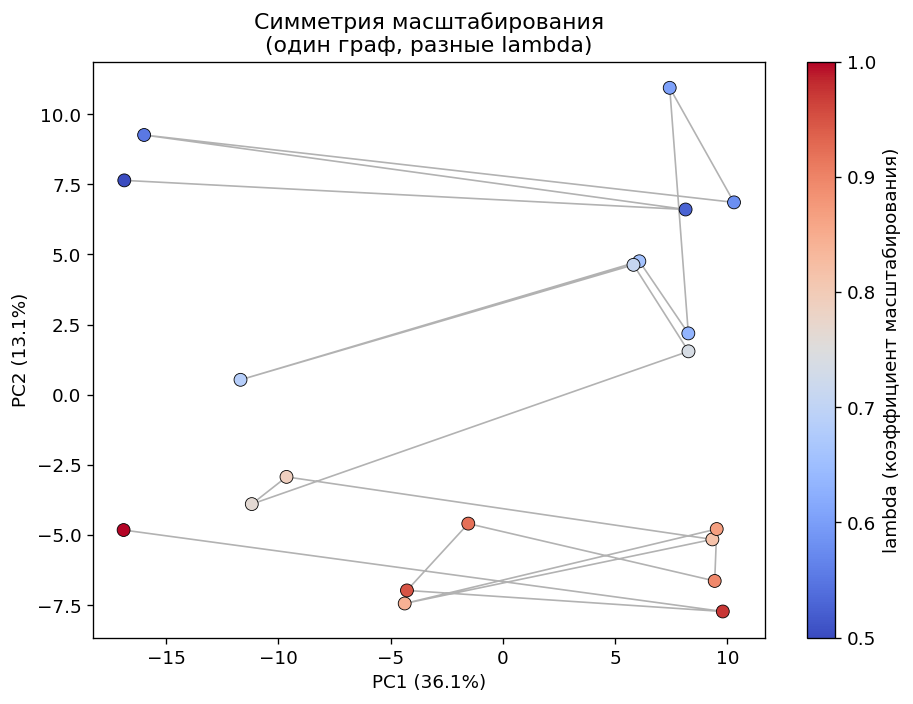

Объяснённая дисперсия (топ-2): 49.2%
Ожидание: симметрия даёт одномерное многообразие (кривую, не обязательно прямую линию)


In [ ]:
# PCA для симметрии масштабирования
pca_scale = PCA(n_components=2)
scale_pca = pca_scale.fit_transform(scaled_matrix)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(scale_pca[:, 0], scale_pca[:, 1],
                     c=lambdas, cmap='coolwarm', s=60, edgecolors='black', linewidths=0.5, zorder=5)
ax.plot(scale_pca[:, 0], scale_pca[:, 1], 'k-', alpha=0.3, linewidth=1)
cbar = plt.colorbar(scatter, ax=ax, label='lambda (коэффициент масштабирования)')
ax.set_xlabel(f'PC1 ({pca_scale.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_scale.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Симметрия масштабирования\n(один граф, разные lambda)')
plt.tight_layout()
plt.savefig('pca_scaling_symmetry.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Объяснённая дисперсия (топ-2): {pca_scale.explained_variance_ratio_.sum()*100:.1f}%')
print('Ожидание: симметрия даёт одномерное многообразие (кривую, не обязательно прямую линию)')


## 11. (Экспериментально) Симметрия перавзвешивания

В статье (Section 3.3.2) анализируется симметрия перавзвешивания (трюк Джонсона):
при преобразовании $\hat{w}(u,v) = w(u,v) + h(u) - h(v)$ для произвольных потенциалов $h: V \to \mathbb{R}$
дерево кратчайших путей сохраняется.

**Внимание:** для Дейкстры (в отличие от Беллмана-Форда в статье) перавзвешивание может
создать отрицательные веса рёбер, что некорректно для алгоритма Дейкстры.
Поэтому мы ограничиваем диапазон потенциалов, чтобы веса оставались положительными.

Этот раздел — экспериментальный. Методика:
1. Берём один граф с весами в $(c, 1-c)$
2. Генерируем случайные потенциалы $h \in (0, c)$
3. Применяем перавзвешивание
4. Проверяем, что все веса $\hat{w} > 0$
5. Извлекаем латентные траектории и визуализируем в PCA

In [ ]:
def generate_reweighted_graphs(base_adj, num_nodes, num_samples, c, config, device, seed=42):
    """
    Генерирует графы с перавзвешиванием Джонсона.

    Args:
        base_adj: базовая матрица смежности (с весами в (c, 1-c))
        c: параметр диапазона для потенциалов
    """
    from torch_geometric.data import Data

    rng = np.random.RandomState(seed)
    data_list = []
    valid_count = 0

    # Маска РЕАЛЬНО существующих рёбер (без диагонали и без структурных "не-рёбер",
    # которые в base_adj равны 0). Раньше проверка положительности шла по ВСЕМ
    # недиагональным элементам, включая отсутствующие рёбра (=0), которые никогда
    # не проходят "> 0" ни при каком c — из-за этого генерировалось 0 графов.
    edge_mask = (base_adj > 0) & (~np.eye(num_nodes, dtype=bool))

    # Базовый экземпляр
    edge_index = np.stack(np.nonzero(base_adj + np.eye(num_nodes)))
    out_nodes = [[] for _ in range(num_nodes)]
    for x, y in edge_index[:, edge_index[0] != edge_index[1]].T:
        out_nodes[x].append(y)

    for _ in range(num_samples * 3):  # генерируем с запасом
        if valid_count >= num_samples:
            break

        # Случайные потенциалы h ∈ (0, c)
        h = rng.uniform(0, c, num_nodes)
        delta = h[:, None] - h[None, :]  # h(u) - h(v) для всех пар (u, v)

        # Перавзвешивание: w_hat(u,v) = w(u,v) + h(u) - h(v), только для реальных рёбер
        reweighted_adj = base_adj.copy()
        reweighted_adj[edge_mask] = base_adj[edge_mask] + delta[edge_mask]

        # Проверяем положительность только там, где рёбра реально есть
        if (reweighted_adj[edge_mask] > 0).all():
            instance = ProblemInstance(reweighted_adj, 0, True, None)

            node_fts, edge_fts, scalars = dijkstra(instance)
            ei = torch.tensor(instance.edge_index).contiguous()
            node_fts_t = torch.transpose(torch.tensor(node_fts), 0, 1)
            edge_fts_t = torch.transpose(
                torch.tensor(edge_fts)[:, ei[0], ei[1]], 0, 1
            )
            scalars_t = torch.transpose(torch.tensor(scalars), 0, 1)
            output_fts = edge_fts_t
            y = output_fts[:, -1, config.output_idx].clone().detach()

            data = Data(
                node_fts=node_fts_t,
                edge_fts=edge_fts_t,
                scalars=scalars_t,
                edge_index=ei,
                y=y,
            ).to(device)
            data_list.append(data)
            valid_count += 1

    print(f'Сгенерировано {valid_count} перавзвешенных графов (из {num_samples} запрошенных)')
    return data_list


In [ ]:
# Генерируем базовый граф с весами в (c, 1-c)
C = 0.25  # параметр диапазона
np.random.seed(SEED + 200)
sampler_rw = ErdosRenyiGraphSampler(config)
base_instance_rw = sampler_rw(ANALYSIS_NUM_NODES)

# Масштабируем веса в диапазон (c, 1-c)
min_w = base_instance_rw.adj[base_instance_rw.adj > 0].min() if (base_instance_rw.adj > 0).any() else 0
max_w = base_instance_rw.adj[base_instance_rw.adj > 0].max() if (base_instance_rw.adj > 0).any() else 1
if max_w > min_w:
    base_adj_rw = (base_instance_rw.adj - min_w) / (max_w - min_w) * (1 - 2*C) + C
    # Обнуляем отсутствующие рёбра
    base_adj_rw[base_instance_rw.adj == 0] = 0
else:
    base_adj_rw = base_instance_rw.adj

# Генерируем перавзвешенные графы
REWEIGHT_NUM = 1000
reweighted_data = generate_reweighted_graphs(
    base_adj_rw, ANALYSIS_NUM_NODES, REWEIGHT_NUM, C, config, DEVICE, seed=SEED + 300
)

# Извлекаем латентные траектории
reweighted_trajectories = []
for data in tqdm(reweighted_data, desc='Перавзвешивание'):
    traj = extract_single_graph_trajectory(model, data, DEVICE)  # [D, T]
    reweighted_trajectories.append(traj.flatten())  # [D*T]

reweighted_matrix = np.stack(reweighted_trajectories)
print(f'Матрица перавзвешивания: {reweighted_matrix.shape}')


Сгенерировано 1000 перавзвешенных графов (из 1000 запрошенных)


Перавзвешивание:  44%|████▍     | 442/1000 [05:16<06:38,  1.40it/s]

In [ ]:
# PCA для симметрии перавзвешивания
pca_rw = PCA(n_components=3)
rw_pca = pca_rw.fit_transform(reweighted_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2D
axes[0].scatter(rw_pca[:, 0], rw_pca[:, 1], c='steelblue', alpha=0.6, s=30, edgecolors='navy', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({pca_rw.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_rw.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'Симметрия перавзвешивания (2D)\nТоп-3: {pca_rw.explained_variance_ratio_.sum()*100:.1f}%')

# 3D
ax3d = fig.add_subplot(122, projection='3d')
ax3d.scatter(rw_pca[:, 0], rw_pca[:, 1], rw_pca[:, 2], c='steelblue', alpha=0.6, s=30, edgecolors='navy', linewidths=0.3)
ax3d.set_xlabel(f'PC1 ({pca_rw.explained_variance_ratio_[0]*100:.1f}%)')
ax3d.set_ylabel(f'PC2 ({pca_rw.explained_variance_ratio_[1]*100:.1f}%)')
ax3d.set_zlabel(f'PC3 ({pca_rw.explained_variance_ratio_[2]*100:.1f}%)')
ax3d.set_title('Симметрия перавзвешивания (3D)')

plt.tight_layout()
plt.savefig('pca_reweighting_symmetry.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Объяснённая дисперсия (топ-3): {pca_rw.explained_variance_ratio_.sum()*100:.1f}%')
print('Ожидание: кластеры должны быть чётко разделены (графы с разным деревом путей)')


## 12. Анализ сходимости (аттрактор)

В статье (Appendix B) показано, что траектории сходятся к аттрактороподобному состоянию:
первые несколько шагов создают большие перемещения в латентном пространстве,
а затем шаги «сливаются» — расстояния между последовательными представлениями быстро убывают.

Проверяем это для DNAR на Дейкстре.

In [ ]:
# Вычисляем расстояния между последовательными шагами в латентном пространстве
# trajectories_agg: [N, D, T]

step_distances = np.zeros((N, T - 1))
for i in range(N):
    for t in range(T - 1):
        step_distances[i, t] = np.linalg.norm(
            trajectories_agg[i, :, t + 1] - trajectories_agg[i, :, t]
        )

mean_distances = step_distances.mean(axis=0)
std_distances = step_distances.std(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, T), mean_distances, 'o-', color='steelblue', linewidth=2, markersize=5, label='Среднее расстояние')
ax.fill_between(range(1, T), mean_distances - std_distances, mean_distances + std_distances,
                 alpha=0.2, color='steelblue', label='± 1 std')
ax.set_xlabel('Шаг процессора')
ax.set_ylabel('L2 расстояние между шагами')
ax.set_title('Сходимость траекторий в латентном пространстве\n(расстояние между последовательными шагами)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('pca_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print('Если расстояния быстро убывают → сходимость к аттрактору')
print(f'Среднее расстояние шаг 1→2: {mean_distances[0]:.4f}')
print(f'Среднее расстояние шаг {T-2}→{T-1}: {mean_distances[-1]:.4f}')
print(f'Отношение: {mean_distances[0] / max(mean_distances[-1], 1e-10):.1f}x')


## 13. Сводка результатов

Ноутбук выполнил PCA-анализ латентного пространства DNAR для алгоритма Дейкстры,
воспроизводя методологию статьи arXiv:2307.08874v2.

### Ключевые результаты для интерпретации:

| Метрика | Trajectory-wise | Step-wise |
|---------|-----------------|-----------|
| Топ-3 объяснённая дисперсия (max) | Запустите для получения значений | Запустите для получения значений |
| Топ-3 объяснённая дисперсия (mean) | Запустите для получения значений | Запустите для получения значений |
| Ожидаемое (равномерное) | 2.3% | 2.3% |

### Аналогии со статьёй:

1. **Низкая размерность:** Если топ-3 PCA компоненты объясняют >>2.3% дисперсии, латентное пространство значительно ниже 128 измерений — структура богатая и низкоразмерная.
2. **Сходимость к аттрактору:** Если расстояния между шагами убывают, траектории сходятся к аттрактороподобному состоянию.
3. **Симметрия масштабирования:** Ожидается одномерное многообразие (кривая) в PCA-пространстве.
4. **Симметрия перавзвешивания:** Ожидается чёткое разделение кластеров в PCA-пространстве.

### Отличия от статьи:

- В статье анализируется **Bellman-Ford** на **LinearPGN/Triplet-GMPNN**
- Здесь анализируется **Дейкстра** на **DNAR** (Discrete Processor с attention)
- DNAR использует дискретные состояния (через bottleneck), но мы анализируем непрерывные представления до дискретизации
- Симметрия перавзвешивания для Дейкстры требует осторожности из-за возможности отрицательных весов

### Сгенерированные файлы:
- `pca_trajectory_wise_2d.png` / `pca_trajectory_wise_3d.png` — trajectory-wise PCA
- `pca_step_wise_2d.png` / `pca_step_wise_3d.png` — step-wise PCA с траекториями
- `pca_explained_variance.png` — анализ размерности
- `pca_aggregation_comparison.png` — сравнение max vs mean
- `pca_scaling_symmetry.png` — симметрия масштабирования
- `pca_reweighting_symmetry.png` — симметрия перавзвешивания
- `pca_convergence.png` — анализ сходимости
